In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy

delaysList = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75]

if "data" not in os.getcwd():
    path = os.path.join(os.getcwd(), 'data', 'Day2')
    os.chdir(path)


(0.0, 250.0)

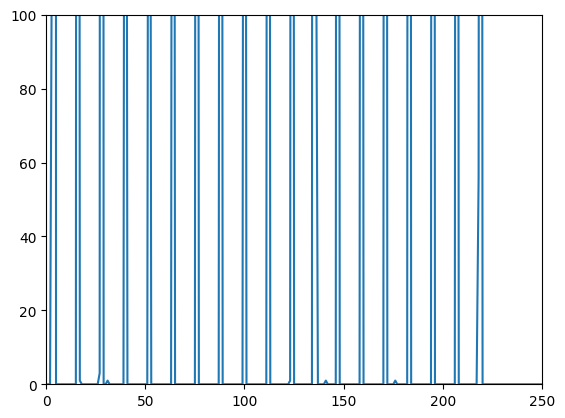

In [35]:

def getNonZeroList(data):
    arr = list()
    for i in range(len(data[:,0])):
        if data[:,1][i] > 5:
            arr.append([data[:,0][i], data[:,1][i]])

    newArr = list()
    newArr.append(arr[0][0])
    for i in range(len(arr)):
        if i > 0:
            if abs(arr[i][0] - arr[i - 1][0]) > 1:
                newArr.append(arr[i][0])
    print(newArr)
    return newArr

fileData = np.loadtxt('chanConversion.txt', dtype='float', delimiter='\t', skiprows=1)
columnTitles = np.loadtxt('chanConversion.txt', dtype='str', delimiter='\t', max_rows=1)

plt.plot(fileData[:,0],fileData[:,1])
plt.ylim((0,100))
plt.xlim((0,250))


In [36]:
def fitting_funct(xVal, a, b):
    '''Fitting function for the given datapoints'''
    return a * xVal + b

popt, _ = scipy.optimize.curve_fit(fitting_funct, delaysList, getNonZeroList(fileData), sigma=1)

realData = scipy.odr.RealData(getNonZeroList(fileData), 
                              delaysList,
                              sx=[1 for i in range(len(getNonZeroList(fileData)))], 
                              sy=[1 for i in range(len(getNonZeroList(fileData)))])
modelODR = scipy.odr.Model(lambda params, xVal: fitting_funct(xVal, params[0], params[1]))
odr      = scipy.odr.ODR(realData, modelODR, beta0=[0,0])
output   = odr.run()

#print(output.beta)
#print(output.cov_beta)

for i in range(len(output.cov_beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0), np.float64(112.0), np.float64(124.0), np.float64(135.0), np.float64(147.0), np.float64(159.0), np.float64(171.0), np.float64(183.0), np.float64(195.0), np.float64(207.0), np.float64(218.0)]
[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0), np.float64(112.0), np.float64(124.0), np.float64(135.0), np.float64(147.0), np.float64(159.0), np.float64(171.0), np.float64(183.0), np.float64(195.0), np.float64(207.0), np.float64(218.0)]
[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0), np.float64(112.0), np.float64(124.0), np.float64(135.0), np.float64(147.0), np.float64(159.0), np.float64(171.0), np.float64(183.0)

[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0), np.float64(112.0), np.float64(124.0), np.float64(135.0), np.float64(147.0), np.float64(159.0), np.float64(171.0), np.float64(183.0), np.float64(195.0), np.float64(207.0), np.float64(218.0)]
[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0), np.float64(112.0), np.float64(124.0), np.float64(135.0), np.float64(147.0), np.float64(159.0), np.float64(171.0), np.float64(183.0), np.float64(195.0), np.float64(207.0), np.float64(218.0)]
Value of slope      : 0.020967352187435874 +/- 0.0035137852374013457
Value of y-intercept: 0.16269202100435823 +/- 0.4539588947890342
[np.float64(3.0), np.float64(16.0), np.float64(28.0), np.float64(40.0), np.float64(52.0), np.float64(64.0), np.float64(76.0), np.float64(88.0), np.float64(100.0

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/7ss23r4n3dn7_w34156zrlw40000gn/T/ipykernel_13316/3719983555.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Time delay ($\mu s$)")


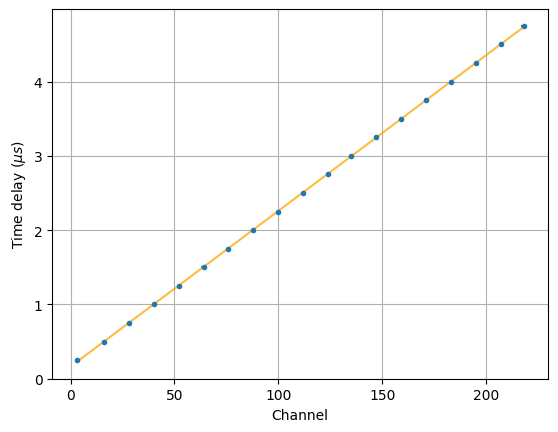

In [37]:
## Plot the data AND the fit

plotRange = np.linspace(min(getNonZeroList(fileData)), max(getNonZeroList(fileData)), 1000)

print(rf"Value of slope      : {output.beta[0]} +/- {np.sqrt(output.cov_beta[0][0])}")
print(rf"Value of y-intercept: {output.beta[1]} +/- {np.sqrt(output.cov_beta[1][1])}")

plt.errorbar(getNonZeroList(fileData), delaysList, xerr=1, fmt='.', label = "Best fit")
plt.plot(plotRange, fitting_funct(plotRange, output.beta[0], output.beta[1]), color = 'orange', alpha = 0.75)
plt.xlabel("Channel")
plt.ylabel("Time delay ($\mu s$)")
# plt.title(f"Data from {filename}")
plt.grid()
plt.show()